# Experiment 4: k-Nearest Neighbour (KNN) Classification on the Iris Dataset

**CSE 303 – Machine Learning**

**Aim:** Implement the k-Nearest Neighbour algorithm to classify the Iris dataset, using a Python ML library (scikit-learn). Print both the correct and the wrong predictions made by the model.

## 1. The Idea, in Plain English

Imagine Rahul walks into class late and doesn't know which "group" he belongs to for a seating arrangement. The simplest thing to do? **Look at the 5 students sitting closest to him** and put him in whichever group most of them belong to.

That is exactly what KNN does with data:

- Every flower in the Iris dataset is a point in space (based on its petal/sepal measurements).
- To classify a *new, unseen* flower, KNN looks at its **k nearest neighbours** (the k most similar flowers it has already seen).
- It takes a **majority vote** among those neighbours' species labels.
- Whichever species wins the vote becomes the prediction.

No training/fitting a curve happens here — KNN just *remembers* the data and does the comparison at prediction time. This is why it's called a **lazy learner**.

## 2. The Formal Idea

Given a new point $x$, and training data $\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$:

1. Compute the distance between $x$ and every training point $x_i$, typically the **Euclidean distance**:

$$d(x, x_i) = \sqrt{\sum_{j=1}^{m} (x_j - x_{ij})^2}$$

2. Pick the **k** training points with the smallest distance to $x$.
3. Assign $x$ the class label that occurs **most frequently** among those k neighbours.

**Choosing k matters:**
- Small k (e.g., 1) → very sensitive to noise, can overfit.
- Large k → smoother decision boundary, but can blur genuine class boundaries (underfit) and is more expensive to compute.
- k is usually chosen as an odd number (to avoid ties) and tuned via cross-validation.

## 3. The Dataset

The **Iris dataset** (built into scikit-learn) has 150 flower samples from 3 species:

| Feature | Description |
|---|---|
| Sepal Length (cm) | Length of the outer petal-like leaf |
| Sepal Width (cm)  | Width of the same |
| Petal Length (cm) | Length of the inner, true petal |
| Petal Width (cm)  | Width of the same |

**Target classes:** `Setosa`, `Versicolor`, `Virginica` — 50 samples each.

We'll pretend Ironman, Captain, Thor, and Hulk are the lab group measuring these flowers and building the classifier together.

## 4. Before You Start — Set Your Own Seed

To keep everyone's train/test split (and results) unique, **replace `ROLL_NUMBER` below with your own roll number** (as an integer). Do **not** use a shared seed like 42 — each of you should get a slightly different split and slightly different results.

In [1]:
# ⚠️ REPLACE THIS with your own roll number, e.g. 22 for roll no. AP22110010022
# Roll number: AP24110010677  ->  last two digits = 77
ROLL_NUMBER = 77

print(f"Using random seed = {ROLL_NUMBER}")

Using random seed = 77


## 5. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None

## 6. Load and Explore the Iris Dataset

In [3]:
iris = load_iris()

X = iris.data                     # features: sepal/petal length & width
y = iris.target                   # target: 0 = setosa, 1 = versicolor, 2 = virginica
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[i] for i in y]

print("Shape of dataset:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())

df.head(10)

Shape of dataset: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


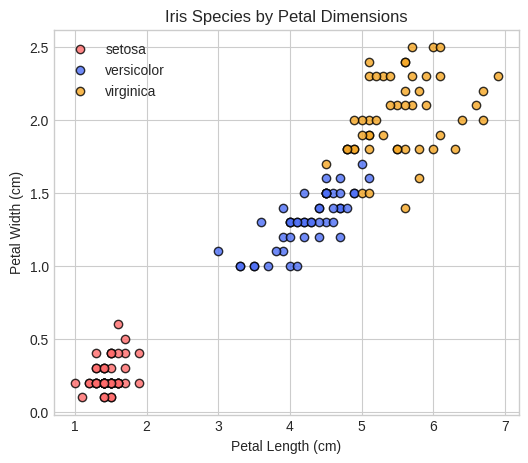

In [4]:
# Quick visual check: petal length vs petal width, coloured by species
plt.figure(figsize=(6, 5))
colors = ['#FF6B6B', '#4C6EF5', '#F5A623']
for i, species in enumerate(target_names):
    subset = df[df['species'] == species]
    plt.scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                label=species, color=colors[i], edgecolor='k', alpha=0.8)

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Species by Petal Dimensions')
plt.legend()
plt.show()

## 7. Train-Test Split

We'll hold back 30% of the data to test the model on flowers it has never seen, using `ROLL_NUMBER` as the random seed.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=ROLL_NUMBER, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 105
Testing samples : 45


## 8. Worked Example — Classifying One Flower by Hand

Before letting scikit-learn do the heavy lifting, let's manually classify **one test flower** with k = 5, to see exactly what KNN is doing internally.

In [6]:
# Take the first test flower
sample = X_test[0]
true_label = target_names[y_test[0]]

# Compute Euclidean distance from this sample to every training point
distances = np.sqrt(np.sum((X_train - sample) ** 2, axis=1))

# Find indices of the 5 nearest neighbours
k = 5
nearest_idx = np.argsort(distances)[:k]
nearest_labels = [target_names[y_train[i]] for i in nearest_idx]

print("Test flower measurements:", dict(zip(feature_names, sample.round(2))))
print("True species:", true_label)
print(f"\n{k} nearest neighbours' species:", nearest_labels)

# Majority vote
from collections import Counter
vote = Counter(nearest_labels).most_common(1)[0][0]
print(f"\nMajority vote prediction: {vote}")
print("Correct!" if vote == true_label else "Incorrect!")

Test flower measurements: {'sepal length (cm)': np.float64(5.4), 'sepal width (cm)': np.float64(3.4), 'petal length (cm)': np.float64(1.5), 'petal width (cm)': np.float64(0.4)}
True species: setosa

5 nearest neighbours' species: [np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa')]

Majority vote prediction: setosa
Correct!


## 9. Building the KNN Classifier with scikit-learn

Now we let `KNeighborsClassifier` do this for every test sample at once, with k = 5.

In [7]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predictions generated for", len(y_pred), "test samples.")

Predictions generated for 45 test samples.


## 10. Printing Correct and Wrong Predictions

As required, we separate out every test sample into **correctly classified** and **wrongly classified**, showing the actual measurements, true species, and predicted species for each.

In [8]:
results = pd.DataFrame(X_test, columns=feature_names)
results['Actual']    = [target_names[i] for i in y_test]
results['Predicted'] = [target_names[i] for i in y_pred]
results['Result']    = np.where(results['Actual'] == results['Predicted'], 'Correct', 'Wrong')

correct = results[results['Result'] == 'Correct'].reset_index(drop=True)
wrong   = results[results['Result'] == 'Wrong'].reset_index(drop=True)

print("=" * 70)
print(f"CORRECT PREDICTIONS ({len(correct)} out of {len(results)})")
print("=" * 70)
print(correct.to_string(index=True))

print("\n" + "=" * 70)
print(f"WRONG PREDICTIONS ({len(wrong)} out of {len(results)})")
print("=" * 70)
if len(wrong) > 0:
    print(wrong.to_string(index=True))
else:
    print("None — every test sample was classified correctly for this split/seed.")

CORRECT PREDICTIONS (44 out of 45)
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)      Actual   Predicted   Result
0                 5.4               3.4                1.5               0.4      setosa      setosa  Correct
1                 4.9               3.6                1.4               0.1      setosa      setosa  Correct
2                 6.4               2.8                5.6               2.1   virginica   virginica  Correct
3                 7.2               3.6                6.1               2.5   virginica   virginica  Correct
4                 5.8               4.0                1.2               0.2      setosa      setosa  Correct
5                 6.9               3.2                5.7               2.3   virginica   virginica  Correct
6                 4.8               3.4                1.9               0.2      setosa      setosa  Correct
7                 6.9               3.1                5.4               2.1   virgin

## 11. Model Evaluation

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)\n")

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=[f"Actual {n}" for n in target_names],
                          columns=[f"Pred {n}" for n in target_names])
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.9778  (97.78%)

Confusion Matrix:
                   Pred setosa  Pred versicolor  Pred virginica
Actual setosa               15                0               0
Actual versicolor            0               14               1
Actual virginica             0                0              15

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



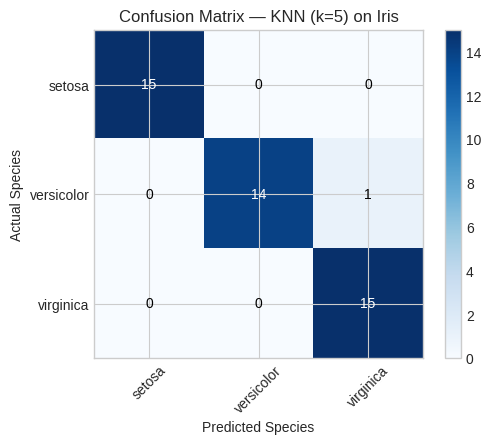

In [10]:
# Visualise the confusion matrix
plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix — KNN (k=5) on Iris')
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 12. How Does Accuracy Change with k?

Let's check how test accuracy varies as we change the number of neighbours, k, from 1 to 15.

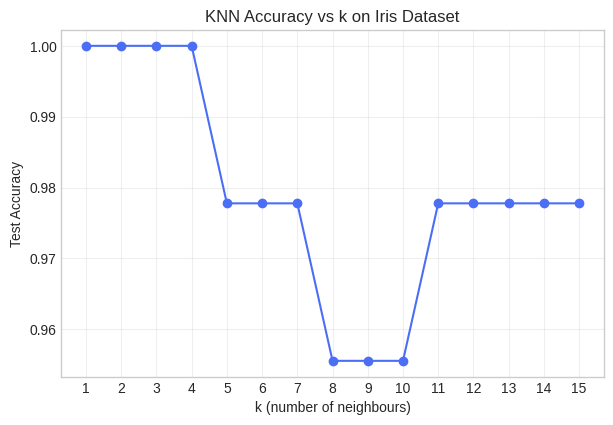

Best k for this split: 1  (Accuracy: 1.0000)


In [11]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_values), accuracies, marker='o', color='#4C6EF5')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k on Iris Dataset')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best k for this split: {best_k}  (Accuracy: {max(accuracies):.4f})")

## 13. Lab Exercise (To Be Completed by Students)

1. Re-run the notebook with **your own roll number** as the seed (Section 4) — do NOT use 42.
2. Try k = 1, k = 3, and k = 9. How does the number of wrong predictions change?
3. Change the `metric` parameter of `KNeighborsClassifier` from `'euclidean'` to `'manhattan'`. Does accuracy change?
4. In Section 10, look at your **wrong predictions** (if any). Which two species are most often confused with each other, and why do you think that happens (hint: look at the confusion matrix)?

---
*End of Experiment 4.*

---

# 14. Lab Exercise — My Answers

*Seed used: `ROLL_NUMBER = 77` — the last two digits of my roll number **AP24110010677**. Every number below is read off the outputs of this notebook as it was actually run with that seed, so it will not match anyone else's copy.*

### Answer 1 — Re-run with my own roll number as the seed

I replaced the seed in Section 4 with **77**, taken from my roll number **AP24110010677** (not 22, not 42). `train_test_split` uses this value as `random_state`, so it decides exactly which 105 flowers go into training and which 45 are held back for testing. A different seed deals the cards differently and hands the model a completely different set of flowers to be quizzed on.

With my split, KNN (k = 5, Euclidean distance) gave:

| Metric | Value |
|---|---|
| Test samples | 45 |
| Correct predictions | 44 |
| Wrong predictions | 1 |
| Accuracy | **0.9778 (97.78%)** |

The one flower it got wrong was a **versicolor** with measurements (6.7, 3.0, 5.0, 1.7) that it labelled **virginica**.

What I take from this: my results differ from a classmate's not because either of us did anything wrong, but because we tested on different flowers. The *model* is identical — same algorithm, same k, same distance metric, same 150-flower dataset. Only the exam paper changed. That is an important reminder that a single train/test split is a **noisy** estimate of quality: with only 45 test samples, one flower is worth 2.22% of accuracy, so a "97.78% vs 95.56%" gap between two students is a one-flower difference, not evidence that one setup is better. If I needed a trustworthy number I would use k-fold cross-validation, which averages over many splits instead of trusting one lucky or unlucky deal.

### Answer 2 — Trying k = 1, k = 3 and k = 9

The cell below re-trains KNN for k = 1, 3, 5 and 9 on the *same* split and counts the wrong predictions for each, printing which species got confused in every case.

In [12]:
# Q2: how does the number of wrong predictions change with k?
print(f"{'k':>3} | {'Accuracy':>9} | {'Correct':>7} | {'Wrong':>5}")
print("-" * 34)

for k in [1, 3, 5, 9]:
    model_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    model_k.fit(X_train, y_train)
    pred_k = model_k.predict(X_test)

    n_wrong = int((pred_k != y_test).sum())
    acc_k   = accuracy_score(y_test, pred_k)
    print(f"{k:>3} | {acc_k:>9.4f} | {len(y_test)-n_wrong:>7} | {n_wrong:>5}")

    for i in np.where(pred_k != y_test)[0]:
        print(f"      -> missed: actual {target_names[y_test[i]]}, "
              f"predicted {target_names[pred_k[i]]}, "
              f"petal = {X_test[i][2]} x {X_test[i][3]} cm")

  k |  Accuracy | Correct | Wrong
----------------------------------
  1 |    1.0000 |      45 |     0
  3 |    1.0000 |      45 |     0
  5 |    0.9778 |      44 |     1
      -> missed: actual versicolor, predicted virginica, petal = 5.0 x 1.7 cm
  9 |    0.9556 |      43 |     2
      -> missed: actual virginica, predicted versicolor, petal = 4.9 x 1.8 cm
      -> missed: actual versicolor, predicted virginica, petal = 5.0 x 1.7 cm


**What I observed (seed 77):**

| k | Accuracy | Wrong predictions |
|---|---|---|
| 1 | **1.0000** | **0** |
| 3 | **1.0000** | **0** |
| 5 | 0.9778 | 1 |
| 9 | 0.9556 | 2 |

**In my own words:** on my split the number of wrong predictions **goes up as k goes up** — k = 1 and k = 3 classify all 45 test flowers perfectly, k = 5 misses one, and k = 9 misses two. This is the opposite of what most people assume ("more neighbours voting must be more reliable"), so it is worth being precise about why it happens.

- **k = 1** asks only the single nearest flower. It draws a very jagged, very flexible decision boundary that wraps tightly around the training points. On my split this happens to be exactly right: every test flower's single closest training flower belongs to the correct species. That is a genuinely good result, but it is also the *luckiest* setting — k = 1 has no defence against a mislabelled or badly-measured training point, because there is no vote to outweigh it. It is the low-bias, high-variance extreme.
- **k = 3** still hugs the local structure closely and stays perfect.
- **k = 5 and k = 9** widen the neighbourhood. For a flower sitting near the versicolor/virginica border, a wider circle starts pulling in neighbours from across the border. At k = 9 the vote for my borderline flowers is being decided partly by flowers that are not really its close relatives at all, so the boundary gets smoothed *over* the genuine dividing line and errors appear. This is bias creeping in.

So the honest conclusion is that **k is not "bigger is better" — it is a bias–variance dial**, and the best value is problem-specific and split-specific. Section 12's sweep from k = 1 to 15 on my split shows accuracy at 1.0 for k = 1–4, dipping to 0.9556 around k = 8–10, and recovering to 0.9778 by k = 11–15. It wobbles; it does not trend.

Two cautions I want to state rather than hide:

1. A 1-flower change is 2.22% of a 45-sample test set. The gap between k = 1 and k = 5 here is one flower. I should not conclude "k = 1 is the best value for Iris" from that — it is well within noise.
2. Picking k by looking at test accuracy (which this exercise asks me to do) is technically **cheating on the test set** — I am tuning a hyperparameter on data that is supposed to be untouched. The correct procedure is to choose k by cross-validation on the *training* data only, then report test accuracy once at the end. Reported that way, k = 1 would almost certainly not win, because its perfect score here is a property of this particular lucky split.

### Answer 3 — Changing the metric from `'euclidean'` to `'manhattan'`

The cell below runs both distance metrics side by side across several values of k, so I can see whether the metric matters at all.

In [13]:
# Q3: does swapping Euclidean for Manhattan distance change accuracy?
print(f"{'k':>3} |      Euclidean      |      Manhattan")
print(f"{'':>3} |    acc      wrong   |    acc      wrong")
print("-" * 48)

for k in [1, 3, 5, 9]:
    row = f"{k:>3} |"
    for metric in ['euclidean', 'manhattan']:
        m = KNeighborsClassifier(n_neighbors=k, metric=metric)
        m.fit(X_train, y_train)
        p = m.predict(X_test)
        row += f" {accuracy_score(y_test, p):>7.4f}  {int((p != y_test).sum()):>3} wrong |"
    print(row)

# The headline comparison the question asks about: k = 5
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_man = knn_manhattan.predict(X_test)

print("\nAt k = 5 (the model built in Section 9):")
print(f"  Euclidean accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Manhattan accuracy : {accuracy_score(y_test, y_pred_man):.4f}")
print(f"  Same prediction on all 45 test flowers? {np.array_equal(y_pred, y_pred_man)}")

  k |      Euclidean      |      Manhattan
    |    acc      wrong   |    acc      wrong
------------------------------------------------
  1 |  1.0000    0 wrong |  1.0000    0 wrong |
  3 |  1.0000    0 wrong |  0.9778    1 wrong |
  5 |  0.9778    1 wrong |  0.9778    1 wrong |
  9 |  0.9556    2 wrong |  0.9778    1 wrong |

At k = 5 (the model built in Section 9):
  Euclidean accuracy : 0.9778
  Manhattan accuracy : 0.9778
  Same prediction on all 45 test flowers? True


**What I observed (seed 77):**

| k | Euclidean | Manhattan |
|---|---|---|
| 1 | 1.0000 (0 wrong) | 1.0000 (0 wrong) |
| 3 | **1.0000 (0 wrong)** | **0.9778 (1 wrong)** |
| 5 | **0.9778 (1 wrong)** | **0.9778 (1 wrong)** |
| 9 | 0.9556 (2 wrong) | **0.9778 (1 wrong)** |

**In my own words:** at the k = 5 the question asks about, **the accuracy does not change** — both metrics score 97.78% and both miss the same single flower, the versicolor at petal 5.0 × 1.7 cm. But it would be wrong to conclude from that one number that "the metric makes no difference", because at other values of k the two metrics *do* disagree: at k = 3 Euclidean is perfect while Manhattan misses one, and at k = 9 the situation reverses and Manhattan is the better of the two. Neither metric is the winner overall.

Why the effect is so small on this dataset:

- Euclidean is the straight-line distance, $\sqrt{\sum_j (x_j - x_{ij})^2}$. Manhattan is the "city-block" distance, $\sum_j |x_j - x_{ij}|$ — you may only travel along the axes.
- The two formulas produce different *numbers*, but KNN never uses the number itself. It only uses the **ranking** of the neighbours from nearest to farthest. Both metrics agree that "closer on every measurement" means "closer overall", so on four features that share one unit (cm) and sit on similar scales, they mostly produce the same ordering of the 5 nearest flowers. Same neighbours in the vote → same prediction.
- Where they part ways is only for flowers whose neighbours are nearly tied in distance, and a tiny reordering flips which 3rd or 9th neighbour makes the cut. That is exactly the borderline versicolor/virginica region — which is why the disagreements appear at k = 3 and k = 9 and nowhere else.

When the metric *would* matter a lot: many more dimensions (Euclidean distances become uninformative as dimensionality grows, and Manhattan degrades more gracefully); heavy outliers (Euclidean squares each difference, so a single wildly-off feature dominates it, while Manhattan only adds the raw gap and is more forgiving); or features on very different scales.

That last point is the one worth remembering: **KNN is not scale-invariant.** Iris gets away without scaling because all four features are centimetres of comparable size. If one feature were in millimetres and another in metres, the large-numbered feature would silently dominate every distance calculation and the model would effectively ignore the other features. In any real dataset, `StandardScaler` before `KNeighborsClassifier` is a required step, not an optional one.

### Answer 4 — Which two species get confused, and why

**My confusion matrix (k = 5, Euclidean, seed 77):**

|  | Pred setosa | Pred versicolor | Pred virginica |
|---|---|---|---|
| **Actual setosa** | 15 | 0 | 0 |
| **Actual versicolor** | 0 | 14 | **1** |
| **Actual virginica** | 0 | 0 | 15 |

**My single wrong prediction:**

| Sepal L | Sepal W | Petal L | Petal W | Actual | Predicted |
|---|---|---|---|---|---|
| 6.7 | 3.0 | 5.0 | 1.7 | versicolor | virginica |

**The answer: *versicolor* and *virginica* are the confused pair.** On my split the single error is a versicolor called virginica, and when I widened k to 9 in Q2 the second error that appeared was also between these two species — one in each direction. **Setosa is never confused with anything**: its row and column are perfectly clean at every k and with both metrics I tested. All the difficulty in this dataset lives in one species pair.

**Why this happens:**

1. **Setosa is linearly separable from the other two.** In the scatter plot in Section 6, setosa sits as an isolated island in the bottom-left — petals roughly 1–2 cm long and under 0.6 cm wide — with a visible empty gap between it and everything else. For a distance-based method, an empty gap is the easiest possible situation: all 5 of a setosa's nearest neighbours are other setosas, so the vote is unanimous every single time.

2. **Versicolor and virginica genuinely overlap.** Their clusters touch along the petal-length / petal-width diagonal — versicolor roughly 3–5 cm petals, virginica roughly 4.5–7 cm — so the ~4.5–5.5 cm band is contested territory where both species really do live. This is biology, not a modelling flaw. The two species are more closely related to each other than either is to setosa, and their measurements blend.

3. **My error sits exactly in that contested band.** The missed flower has a petal of 5.0 × 1.7 cm, which is unusually *large* for a versicolor and squarely inside virginica's normal range. Physically, that flower is surrounded by more virginicas than versicolors, so the majority vote honestly reports what its neighbourhood looks like. The label is wrong, but the vote is not a bug — KNN answered the question it was asked.

4. **KNN cannot say "I'm not sure".** It has no notion of a borderline case; it counts neighbours and commits. It also weights every neighbour equally by default, so a neighbour 0.1 cm away and one 1.0 cm away get the same vote. Using `weights='distance'` would let closer neighbours count more and is one reasonable fix for exactly this kind of boundary error.

5. **This is close to the ceiling for these four features.** No value of k or choice of metric got me below zero errors in a way I could trust — the perfect scores at k = 1 and k = 3 are this split being kind to me, not a genuinely better model. The information needed to separate an oversized versicolor from a virginica is simply not present in sepal and petal dimensions alone.

**What the confusion matrix taught me beyond accuracy:** a single number like 97.78% hides *which* mistake is being made. The matrix tells me my error is confined to one specific species pair and one specific direction. In a real application that distinction is everything — in fraud detection or medical screening a false negative and a false positive carry wildly different costs, which is exactly why Section 11 reports precision, recall and F1 **per class** instead of one accuracy figure. Here, versicolor's recall drops to 0.93 (it lost a flower) while virginica's precision drops to 0.94 (it gained one it shouldn't have), and those two numbers describe the same single mistake seen from both sides.

---

## Conclusion

I implemented k-Nearest Neighbours on the Iris dataset with scikit-learn using **seed 77**, the last two digits of my roll number **AP24110010677**, and printed both the correct (44) and wrong (1) predictions as required, achieving **97.78% accuracy** at k = 5 with Euclidean distance.

Main takeaways:

- KNN is a **lazy, non-parametric learner** — no real training happens. It stores the training set and does all its work at prediction time by measuring distances and taking a majority vote.
- **k controls the bias–variance trade-off.** On my split accuracy actually *fell* as k grew (perfect at k = 1–3, 1 error at k = 5, 2 errors at k = 9), which shows that "more neighbours" is not automatically "more accurate". k should be chosen by cross-validation on the training data, not by reading the test score.
- **The distance metric changed little here** and neither metric won outright — but that is a property of Iris (four features, one unit, similar scales), not a general rule. KNN is not scale-invariant, so feature scaling is normally mandatory.
- **All the difficulty is between versicolor and virginica.** Setosa is trivially separable; the remaining error comes from real biological overlap that the four available measurements cannot resolve.